## Methodology

### Training

A ResNet Model is trained on 15,000 CIFAR-10 samples using SGD with standard configuration ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, cosine annealing, 15 epochs). After every mini-batch update the full parameter vector $\theta_t \in \mathbb{R}^{78042}$ is stored in float16, yielding a trajectory of $T \approx 1{,}760$ iterates.

### Graph Construction

Pairwise Euclidean distances between all iterates are computed and fed into average-linkage hierarchical clustering. The linkage threshold $\varepsilon$ is found by binary search to yield a target number of clusters $K$. Each cluster becomes a node in a directed quotient graph; a directed edge $(u,v)$ is added (or its weight incremented) whenever consecutive iterates transition between clusters $u$ and $v$. Nodes are assigned chronological IDs by mean iterate index.

### Random Walk Baseline

An isotropic random walk in $\mathbb{R}^{78042}$ is generated with the same number of steps $T$ and median step size as the SGD trajectory, starting from $\theta_1$. The identical clustering and graph-building pipeline is applied, with $\varepsilon$ chosen to match the SGD node count exactly.

### Analyses

**Node size distribution.** Node size (number of iterates assigned to a cluster) is compared across chronological node index for SGD vs.\ random walk. An increasing trend for SGD indicates progressive convergence into a flat basin; the random walk serves as a uniform-distribution null.

**Tortuosity.** Per-node tortuosity is defined as the ratio of accumulated intra-node step length to end-to-end Euclidean distance between first and last iterate. Values near 1 indicate directional movement; large values indicate meandering. SGD and random walk tortuosity distributions are compared via box plots and chronological line plots.

**Linear loss interpolation.** For selected nodes, the loss is evaluated along the straight line $\theta(\alpha) = (1-\alpha)\,\theta_0 + \alpha\,\theta_1$ between the node's first and last iterate ($N_\alpha = 15$ points, fixed 1,024-sample eval subset). Residuals between actual iterate losses and the linear interpolant at matched normalised positions $\alpha_t$ quantify intra-node loss barriers, following Goodfellow et al.\ (2015).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from torch.utils.data import Subset
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
import networkx as nx
import copy

torch.manual_seed(42)
np.random.seed(42)

# ── Alle Trainingsparameter ───────────────────────────────────────────────────
EPOCHS        = 15
BATCH_SIZE    = 128
LR            = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4
TRAIN_SIZE    = 15000
TEST_SIZE     = 5000
DEVICE        = "mps" if torch.backends.mps.is_available() else "cpu"

# ── Graph-Parameter ───────────────────────────────────────────────────────────
TARGET_NODES  = 40        # angestrebte Knotenanzahl im Quotientengraphen

# ── Iterate-Selektion (Perzentile der Trajektorie) ────────────────────────────
PERC_LOW      = 0
PERC_HIGH     = 100

# ── Phasen-Analyse ─────────────────────────────────────────────────────────────
N_PHASES      = 3
PHASE_TARGET_NODES = 30   # eigene, kleinere Zielknotenzahl pro Phase

# ── Eval-Subset für Loss-Berechnungen (Interpolation etc.) ───────────────────
EVAL_SUBSET_SIZE = 1024

print(f"Device:       {DEVICE}")
print(f"Epochs:       {EPOCHS}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"LR:           {LR}  |  Momentum: {MOMENTUM}  |  WD: {WEIGHT_DECAY}")
print(f"Iterate-Selektion: Perzentil {PERC_LOW}–{PERC_HIGH}")

Device:       mps
Epochs:       15
Batch Size:   128
LR:           0.1  |  Momentum: 0.9  |  WD: 0.0001
Iterate-Selektion: Perzentil 0–100


In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3,
                                  stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3,
                                  stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet20(nn.Module):
    """
    Verkleinerte ResNet-Variante: 1 BasicBlock pro Stage statt 3 (wie bei ResNet-20).
    3 Stages * 2 Conv-Layer/Block + 1 Stem-Conv + 1 FC = 8 gewichtete Layer.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(16, 16, 1, stride=1)
        self.layer2  = self._make_layer(16, 32, 1, stride=2)
        self.layer3  = self._make_layer(32, 64, 1, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))


model    = ResNet20().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameter:              {n_params:,}")
print(f"RAM/Iterate (float16):  {n_params * 2 / 1e6:.2f} MB")

Parameter:              78,042
RAM/Iterate (float16):  0.16 MB


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

trainset = Subset(torchvision.datasets.CIFAR10(
    './data', train=True,  download=True, transform=transform_train),
    range(TRAIN_SIZE))
testset  = Subset(torchvision.datasets.CIFAR10(
    './data', train=False, download=True, transform=transform_test),
    range(TEST_SIZE))

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
testloader  = torch.utils.data.DataLoader(
    testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Fixes Eval-Subset (für konsistente Loss-Berechnungen entlang Interpolationen)
eval_subset = Subset(torchvision.datasets.CIFAR10(
    './data', train=True, download=True, transform=transform_test),  # ohne Augmentation!
    range(EVAL_SUBSET_SIZE))
eval_loader_fixed = torch.utils.data.DataLoader(
    eval_subset, batch_size=EVAL_SUBSET_SIZE, shuffle=False, num_workers=0)
eval_inputs_fixed, eval_labels_fixed = next(iter(eval_loader_fixed))
eval_inputs_fixed, eval_labels_fixed = (eval_inputs_fixed.to(DEVICE),
                                         eval_labels_fixed.to(DEVICE))

print(f"Train: {len(trainset)}  |  Test: {len(testset)}  |  Eval-Subset: {EVAL_SUBSET_SIZE}")

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train: 15000  |  Test: 5000  |  Eval-Subset: 1024


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, train_accs, test_accs = [], [], []
iterates   = []   # Parametervektoren NACH jedem Update
grad_snaps = []   # rohe Mini-Batch-Gradienten VOR dem Update (für Cosinus-Analyse)

def get_snap(model):
    return np.concatenate([p.detach().cpu().numpy().ravel()
                           for p in model.parameters()]).astype(np.float16)

def get_grad_snap(model):
    return np.concatenate([p.grad.detach().cpu().numpy().ravel()
                           for p in model.parameters()]).astype(np.float16)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        grad_snaps.append(get_grad_snap(model))   # roher Gradient VOR step()
        optimizer.step()
        iterates.append(get_snap(model))
        running_loss += loss.item() * inputs.size(0)
        with torch.no_grad():
            correct += model(inputs).max(1)[1].eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = 100. * correct / total
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            correct += model(inputs).max(1)[1].eq(labels).sum().item()
            total   += labels.size(0)
    test_acc = 100. * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    scheduler.step()
    print(f"Epoch {epoch:3d}/{EPOCHS}  Loss={train_loss:.4f}  "
          f"Train={train_acc:.1f}%  Test={test_acc:.1f}%  "
          f"Iterates={len(iterates)}")

iterates        = np.stack(iterates).astype(np.float32)
grad_snaps      = np.stack(grad_snaps).astype(np.float32)
T_total         = len(iterates)
steps_per_epoch = T_total // EPOCHS
print(f"\nGesamt-Iterates: {iterates.shape}  |  RAM: {iterates.nbytes/1e6:.1f} MB")
print(f"Gesamt-Gradienten: {grad_snaps.shape}  |  RAM: {grad_snaps.nbytes/1e6:.1f} MB")

Epoch   1/15  Loss=1.8560  Train=32.8%  Test=36.4%  Iterates=118
Epoch   2/15  Loss=1.5967  Train=42.2%  Test=43.5%  Iterates=236
Epoch   3/15  Loss=1.4355  Train=49.3%  Test=50.9%  Iterates=354
Epoch   4/15  Loss=1.3020  Train=54.9%  Test=52.2%  Iterates=472
Epoch   5/15  Loss=1.1885  Train=58.9%  Test=55.4%  Iterates=590
Epoch   6/15  Loss=1.1017  Train=62.3%  Test=57.4%  Iterates=708
Epoch   7/15  Loss=1.0315  Train=64.9%  Test=59.6%  Iterates=826
Epoch   8/15  Loss=0.9908  Train=66.2%  Test=61.9%  Iterates=944
Epoch   9/15  Loss=0.9360  Train=67.5%  Test=64.5%  Iterates=1062
Epoch  10/15  Loss=0.8933  Train=69.3%  Test=66.5%  Iterates=1180
Epoch  11/15  Loss=0.8480  Train=70.6%  Test=66.9%  Iterates=1298
Epoch  12/15  Loss=0.8068  Train=71.9%  Test=69.7%  Iterates=1416
Epoch  13/15  Loss=0.7858  Train=72.9%  Test=70.3%  Iterates=1534
Epoch  14/15  Loss=0.7637  Train=73.3%  Test=70.5%  Iterates=1652
Epoch  15/15  Loss=0.7457  Train=73.9%  Test=70.3%  Iterates=1770

Gesamt-Iterates: 

Selektion: Perzentil 0–100
  Iterates 0–1769  |  Epochen 0.0–15.0
  T_sel = 1769  |  RAM: 552.2 MB


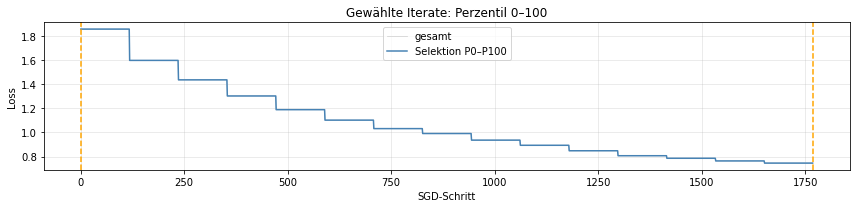


Berechne Distanzmatrix ...
Distanzmatrix: (1769, 1769)  |  RAM: 25.0 MB
Min=0.0049  Median=7.3893  Max=21.5915  Std/Mean=0.6893


In [6]:
idx_low  = int(np.percentile(np.arange(T_total), PERC_LOW))
idx_high = int(np.percentile(np.arange(T_total), PERC_HIGH))
iterates_sel = iterates[idx_low:idx_high]
grads_sel    = grad_snaps[idx_low:idx_high]
T_sel        = len(iterates_sel)

epoch_low  = idx_low  / steps_per_epoch
epoch_high = idx_high / steps_per_epoch

print(f"Selektion: Perzentil {PERC_LOW}–{PERC_HIGH}")
print(f"  Iterates {idx_low}–{idx_high}  |  Epochen {epoch_low:.1f}–{epoch_high:.1f}")
print(f"  T_sel = {T_sel}  |  RAM: {iterates_sel.nbytes/1e6:.1f} MB")

fig, ax = plt.subplots(figsize=(12, 3))
epoch_of_sel = [min(int(t/T_total*EPOCHS), EPOCHS-1) for t in range(T_total)]
ax.plot(range(T_total), [train_losses[e] for e in epoch_of_sel],
        color='lightgray', lw=0.8, label='gesamt')
ax.plot(range(idx_low, idx_high),
        [train_losses[e] for e in epoch_of_sel[idx_low:idx_high]],
        color='steelblue', lw=1.5, label=f'Selektion P{PERC_LOW}–P{PERC_HIGH}')
ax.axvline(idx_low,  color='orange', linestyle='--', lw=1.5)
ax.axvline(idx_high, color='orange', linestyle='--', lw=1.5)
ax.set(xlabel='SGD-Schritt', ylabel='Loss',
       title=f'Gewählte Iterate: Perzentil {PERC_LOW}–{PERC_HIGH}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nBerechne Distanzmatrix ...")
dist_vec    = pdist(iterates_sel, metric='euclidean')
dist_matrix = squareform(dist_vec)
print(f"Distanzmatrix: {dist_matrix.shape}  |  RAM: {dist_matrix.nbytes/1e6:.1f} MB")
print(f"Min={dist_vec.min():.4f}  Median={np.median(dist_vec):.4f}  "
      f"Max={dist_vec.max():.4f}  Std/Mean={dist_vec.std()/dist_vec.mean():.4f}")

Hierarchical clustering (average linkage) ...
Done.


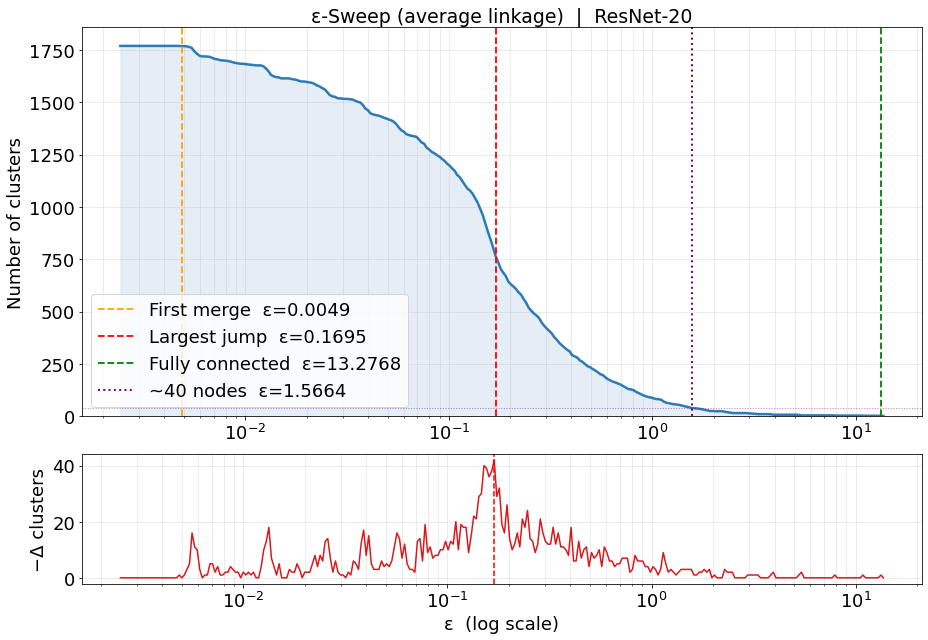


Selected ε = 1.56638  →  target number of nodes ≤ 40


In [84]:
print("Hierarchical clustering (average linkage) ...")
Z = linkage(dist_vec, method='average')
print("Done.")

N_SAMPLES  = 300
eps_sample = np.geomspace(Z[:,2].min()*0.5, Z[:,2].max()*1.05, N_SAMPLES)
n_clusters = np.array([fcluster(Z, t=e, criterion='distance').max()
                        for e in eps_sample])

idx_first  = int(np.argmax(n_clusters < T_sel))
idx_perc   = int(np.argmax(-np.diff(n_clusters.astype(float)))) + 1
idx_conn   = int(np.argmax(n_clusters == 1))
idx_target = int(np.argmax(n_clusters <= TARGET_NODES))
eps_target = eps_sample[idx_target]

# ── Font sizes ────────────────────────────────────────────────────────────────
FS_TITLE  = 19
FS_LABEL  = 18
FS_TICK   = 18
FS_LEGEND = 18

fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios': [3, 1]})

# ── Upper panel ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.semilogx(eps_sample, n_clusters, color='#2c7bb6', lw=2.5)
ax.fill_between(eps_sample, 0, n_clusters, alpha=0.12, color='#2c7bb6')

ax.axvline(eps_sample[idx_first], color='orange', ls='--', lw=1.8,
           label=f'First merge  ε={eps_sample[idx_first]:.4f}')
ax.axvline(eps_sample[idx_perc],  color='red',    ls='--', lw=1.8,
           label=f'Largest jump  ε={eps_sample[idx_perc]:.4f}')
ax.axvline(eps_sample[idx_conn],  color='green',  ls='--', lw=1.8,
           label=f'Fully connected  ε={eps_sample[idx_conn]:.4f}')
ax.axvline(eps_target, color='purple', ls=':', lw=2.0,
           label=f'~{TARGET_NODES} nodes  ε={eps_target:.4f}')
ax.axhline(TARGET_NODES, color='purple', ls=':', lw=1.0, alpha=0.5)

ax.set_ylabel('Number of clusters', fontsize=FS_LABEL)
ax.set_ylim(0, T_sel * 1.05)
ax.set_title('ε-Sweep (average linkage)  |  ResNet-20',
             fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEGEND)
ax.grid(True, which='both', alpha=0.3)
ax.tick_params(labelsize=FS_TICK)

# ── Lower panel ───────────────────────────────────────────────────────────────
ax = axes[1]
delta = -np.diff(n_clusters.astype(float))
ax.semilogx(eps_sample[1:], delta, color='#d7191c', lw=1.5)
ax.axvline(eps_sample[idx_perc], color='red', ls='--', lw=1.5)

ax.set_xlabel('ε  (log scale)', fontsize=FS_LABEL)
ax.set_ylabel('−Δ clusters', fontsize=FS_LABEL)
#ax.set_title('Merge rate', fontsize=FS_TITLE - 1, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.tick_params(labelsize=FS_TICK)

plt.tight_layout()
plt.show()

print(f"\nSelected ε = {eps_target:.5f}  →  target number of nodes ≤ {TARGET_NODES}")

In [8]:
def build_quotient(iterates, labels, label=''):
    n = labels.max() + 1
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for t in range(len(labels) - 1):
        u, v = int(labels[t]), int(labels[t+1])
        if G.has_edge(u, v): G[u][v]['weight'] += 1
        else:                G.add_edge(u, v, weight=1)
    for nid in range(n):
        times = np.where(labels == nid)[0]
        G.nodes[nid]['size']      = len(times)
        G.nodes[nid]['mean_time'] = float(np.mean(times)) if len(times) else 0.0
        G.nodes[nid]['centroid']  = (iterates[times].mean(axis=0)
                                     if len(times) else np.zeros(iterates.shape[1]))
        G.nodes[nid]['times']     = times
    n_self = sum(1 for u, v in G.edges if u == v)
    print(f"  {label}: {n} Knoten | {G.number_of_edges()} Kanten | "
          f"{n_self} Selbstschleifen")
    return G

def relabel_chronologically(G, labels):
    """Benennt Knoten 0..n-1 nach aufsteigendem mean_time, gibt neues G und neue labels zurück."""
    order = sorted(G.nodes, key=lambda n: G.nodes[n]['mean_time'])
    remap = {old: new for new, old in enumerate(order)}
    G_new = nx.DiGraph()
    G_new.add_nodes_from(range(len(order)))
    for u, v, d in G.edges(data=True):
        u2, v2 = remap[u], remap[v]
        if G_new.has_edge(u2, v2):
            G_new[u2][v2]['weight'] += d['weight']
        else:
            G_new.add_edge(u2, v2, weight=d['weight'])
    for old, new in remap.items():
        G_new.nodes[new].update(G.nodes[old])
    labels_new = np.array([remap[l] for l in labels])
    return G_new, labels_new

labels_sgd_raw  = fcluster(Z, t=eps_target, criterion='distance') - 1
n_nodes_sgd     = labels_sgd_raw.max() + 1
print(f"SGD-Graph (vor Umbenennung): {n_nodes_sgd} Knoten")

G_sgd_raw = build_quotient(iterates_sel, labels_sgd_raw, 'SGD (raw)')
G_sgd, labels_sgd = relabel_chronologically(G_sgd_raw, labels_sgd_raw)
print(f"SGD-Graph chronologisch umbenannt: Knoten 0 (früh) ... {n_nodes_sgd-1} (spät)")

SGD-Graph (vor Umbenennung): 39 Knoten
  SGD (raw): 39 Knoten | 77 Kanten | 39 Selbstschleifen
SGD-Graph chronologisch umbenannt: Knoten 0 (früh) ... 38 (spät)


In [9]:
# ── Random-Walk-Parameter ─────────────────────────────────────────────────────
RW_STEP_MEAN  = float(np.median(
    [dist_matrix[t, t+1] for t in range(min(T_sel-1, 500))]))
RW_STEP_STD   = RW_STEP_MEAN * 0.3
RW_N_STEPS    = T_sel
RW_DIM        = iterates_sel.shape[1]
RW_START      = iterates_sel[0].copy()

print(f"Random Walk:  Dim={RW_DIM:,}  |  Steps={RW_N_STEPS}")
print(f"  Schrittweite: μ={RW_STEP_MEAN:.4f}  σ={RW_STEP_STD:.4f}")

rw_iterates = np.empty((RW_N_STEPS, RW_DIM), dtype=np.float32)
rw_iterates[0] = RW_START

rng = np.random.default_rng(42)
for t in range(1, RW_N_STEPS):
    direction = rng.standard_normal(RW_DIM).astype(np.float32)
    direction /= np.linalg.norm(direction)
    step_size = max(0.0, rng.normal(RW_STEP_MEAN, RW_STEP_STD))
    rw_iterates[t] = rw_iterates[t-1] + step_size * direction

print("Random Walk fertig.")

print("Berechne RW-Distanzmatrix ...")
rw_dist_vec    = pdist(rw_iterates, metric='euclidean')
rw_dist_matrix = squareform(rw_dist_vec)
print(f"  Min={rw_dist_vec.min():.4f}  Median={np.median(rw_dist_vec):.4f}  "
      f"Max={rw_dist_vec.max():.4f}")

print("RW Clustering (average linkage) ...")
Z_rw = linkage(rw_dist_vec, method='average')

# ── ε so wählen, dass RW GENAU dieselbe Knotenanzahl wie SGD bekommt ──────────
def find_eps_for_n_nodes(Z_, target_n, lo=None, hi=None, n_iter=60):
    """Bisektion auf ε, um eine Ziel-Clusteranzahl zu erreichen (so nah wie möglich)."""
    if lo is None: lo = Z_[:,2].min() * 0.1
    if hi is None: hi = Z_[:,2].max() * 1.5
    best_eps, best_n, best_diff = hi, fcluster(Z_, t=hi, criterion='distance').max(), np.inf
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        n_mid = fcluster(Z_, t=mid, criterion='distance').max()
        diff = abs(n_mid - target_n)
        if diff < best_diff:
            best_diff, best_eps, best_n = diff, mid, n_mid
        if n_mid > target_n:
            lo = mid          # zu viele Cluster -> ε erhöhen
        elif n_mid < target_n:
            hi = mid           # zu wenige Cluster -> ε senken
        else:
            return mid, n_mid
    return best_eps, best_n

eps_rw_target, n_nodes_rw_found = find_eps_for_n_nodes(Z_rw, n_nodes_sgd)
print(f"RW: ε={eps_rw_target:.5f} → {n_nodes_rw_found} Knoten "
      f"(Ziel: {n_nodes_sgd})")

labels_rw_raw = fcluster(Z_rw, t=eps_rw_target, criterion='distance') - 1
n_nodes_rw    = labels_rw_raw.max() + 1
print(f"RW-Graph (vor Umbenennung): {n_nodes_rw} Knoten")

Random Walk:  Dim=78,042  |  Steps=1769
  Schrittweite: μ=0.1705  σ=0.0512
Random Walk fertig.
Berechne RW-Distanzmatrix ...
  Min=0.0163  Median=4.1210  Max=7.5661
RW Clustering (average linkage) ...
RW: ε=1.03163 → 39 Knoten (Ziel: 39)
RW-Graph (vor Umbenennung): 39 Knoten


  Random Walk (raw): 39 Knoten | 77 Kanten | 39 Selbstschleifen
RW graph (relabelled chronologically): 39 nodes  (SGD: 39)


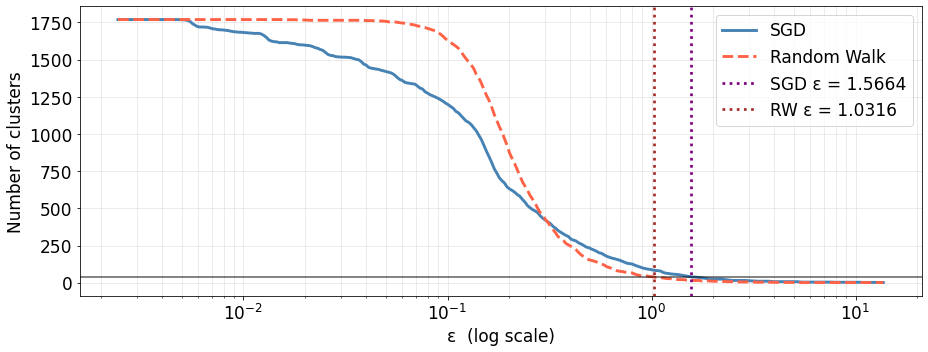

In [71]:
G_rw_raw = build_quotient(rw_iterates, labels_rw_raw, 'Random Walk (raw)')
G_rw, labels_rw = relabel_chronologically(G_rw_raw, labels_rw_raw)
print(f"RW graph (relabelled chronologically): {G_rw.number_of_nodes()} nodes  "
      f"(SGD: {G_sgd.number_of_nodes()})")

n_clusters_rw = np.array([fcluster(Z_rw, t=e, criterion='distance').max()
                           for e in eps_sample])

# ── Font sizes ────────────────────────────────────────────────────────────────
FS_TITLE  = 18
FS_LABEL  = 17
FS_TICK   = 17
FS_LEGEND = 17

fig, ax = plt.subplots(figsize=(13, 5))

ax.semilogx(eps_sample, n_clusters,    color='steelblue', lw=2.9,
            label='SGD')
ax.semilogx(eps_sample, n_clusters_rw, color='tomato',    lw=2.9, ls='--',
            label='Random Walk')
ax.axvline(eps_target,    color='purple', ls=':', lw=2.7,
           label=f'SGD ε = {eps_target:.4f}')
ax.axvline(eps_rw_target, color='brown',  ls=':', lw=2.7,
           label=f'RW ε = {eps_rw_target:.4f}')
ax.axhline(n_nodes_sgd, color='black', ls='-', lw=1.9, alpha=0.5)

ax.set_xlabel('ε  (log scale)',    fontsize=FS_LABEL)
ax.set_ylabel('Number of clusters', fontsize=FS_LABEL)
#ax.set_title(f'ε-Sweep comparison: SGD vs. Random Walk  ',
 #            fontsize=FS_TITLE, fontweight='bold')
ax.legend(fontsize=FS_LEGEND)
ax.grid(True, which='both', alpha=0.3)
ax.tick_params(labelsize=FS_TICK)

plt.tight_layout()
plt.show()

In [24]:
from scipy.interpolate import make_interp_spline
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

print("Imports OK.")

Imports OK.


In [25]:
all_sizes_sgd   = np.array([G_sgd.nodes[i]['size'] for i in G_sgd.nodes])
all_sizes_rw    = np.array([G_rw.nodes[i]['size']  for i in G_rw.nodes])
GLOBAL_MIN_SIZE = float(min(all_sizes_sgd.min(), all_sizes_rw.min()))
GLOBAL_MAX_SIZE = float(max(all_sizes_sgd.max(), all_sizes_rw.max()))

print(f"SGD  sizes : min={all_sizes_sgd.min()}  max={all_sizes_sgd.max()}  "
      f"μ={all_sizes_sgd.mean():.1f}")
print(f"RW   sizes : min={all_sizes_rw.min()}   max={all_sizes_rw.max()}  "
      f"μ={all_sizes_rw.mean():.1f}")
print(f"Shared scale : min={GLOBAL_MIN_SIZE:.0f}  max={GLOBAL_MAX_SIZE:.0f}")

SGD  sizes : min=7  max=478  μ=45.4
RW   sizes : min=18   max=74  μ=45.4
Shared scale : min=7  max=478


In [26]:
def plot_graph_spring(G, ax,
                      title=None,
                      show_title=True,
                      node_color_attr='mean_time',
                      cmap='coolwarm',
                      show_labels=True,
                      global_min_size=None,
                      global_max_size=None,
                      min_node_area=300,
                      max_node_area=4000,
                      edge_alpha=0.45,
                      fs_title=13,
                      fs_tick=9,
                      fs_node=9,
                      fs_cbar=10,
                      title_pad=10,
                      spring_k=2.0,
                      spring_iter=120,
                      seed=42):
    """
    Spring-layout quotient graph.
    Node area mapped linearly from [global_min_size, global_max_size]
    → [min_node_area, max_node_area].
    Node IDs written in white inside each node.
    """
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'Empty graph', ha='center', va='center',
                transform=ax.transAxes)
        return

    # ── Node areas ────────────────────────────────────────────────────────────
    nodes   = list(G.nodes)
    sizes   = np.array([G.nodes[n]['size'] for n in nodes], dtype=float)
    ref_min = float(global_min_size) if global_min_size is not None else sizes.min()
    ref_max = float(global_max_size) if global_max_size is not None else sizes.max()
    t_sz    = np.clip((sizes - ref_min) / max(ref_max - ref_min, 1e-9), 0., 1.)
    areas   = min_node_area + (max_node_area - min_node_area) * t_sz

    # ── Layout & colours ──────────────────────────────────────────────────────
    pos    = nx.spring_layout(G, seed=seed, k=spring_k, iterations=spring_iter)
    colors = [G.nodes[n].get(node_color_attr, 0) for n in nodes]

    # ── Edges ─────────────────────────────────────────────────────────────────
    edges_ns = [(u, v) for u, v in G.edges if u != v]
    ew       = [G[u][v]['weight'] for u, v in edges_ns]
    max_w    = max(ew) if ew else 1

    nx.draw_networkx_edges(
        G, pos, edgelist=edges_ns, ax=ax,
        width=[0.5 + 3.0 * w / max_w for w in ew],
        alpha=edge_alpha, edge_color='#444444',
        arrows=True, arrowsize=14,
        connectionstyle='arc3,rad=0.12')

    # ── Nodes ─────────────────────────────────────────────────────────────────
    nc = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=colors, cmap=cmap,
        node_size=list(areas),
        linewidths=1.0, edgecolors='white')

    if show_labels:
        nx.draw_networkx_labels(
            G, pos, ax=ax,
            labels={n: str(n) for n in nodes},
            font_size=fs_node, font_weight='bold', font_color='white')

    # ── Colourbar ─────────────────────────────────────────────────────────────
    cb = plt.colorbar(nc, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('Mean time step', fontsize=fs_cbar)
    cb.ax.tick_params(labelsize=fs_tick)

    ax.axis('off')

    if show_title and title:
        ax.set_title(title, fontsize=fs_title, fontweight='bold', pad=title_pad)

In [102]:
def plot_graph_chain(G, ax,
                     title=None,
                     show_title=True,
                     nodes_per_row=8,
                     col_spacing=3.0,
                     row_spacing=4.2,
                     min_radius=0.20,
                     max_radius=1.10,
                     size_exponent=1.0,
                     global_min_size=None,
                     global_max_size=None,
                     corner_bulge=0.7,
                     cmap_name='coolwarm',
                     path_color='#c8c8c8',
                     path_lw=5,
                     fs_title=11,
                     fs_tick=9,
                     fs_node=11,
                     fs_cbar=10,
                     title_pad=20):
    """
    Ordered snake/meander chain layout.
    Nodes coloured blue (early) → red (late).
    Iterate count shown above each node (no ID inside the circle).
    Radius linearly mapped from [global_min_size, global_max_size]
    → [min_radius, max_radius].
    """
    n = G.number_of_nodes()
    if n == 0:
        ax.text(.5, .5, 'Empty graph', ha='center', va='center',
                transform=ax.transAxes)
        return

    # ── Radii ─────────────────────────────────────────────────────────────────
    sizes   = np.array([G.nodes[i]['size'] for i in range(n)], dtype=float)
    ref_min = float(global_min_size) if global_min_size is not None else sizes.min()
    ref_max = float(global_max_size) if global_max_size is not None else sizes.max()
    t_sz    = np.clip((sizes - ref_min) / max(ref_max - ref_min, 1e-9), 0., 1.)
    radii   = min_radius + (max_radius - min_radius) * t_sz ** size_exponent

    # ── Snake positions ───────────────────────────────────────────────────────
    pos   = np.zeros((n, 2))
    x_max = (nodes_per_row - 1) * col_spacing
    for i in range(n):
        row = i // nodes_per_row
        col = i %  nodes_per_row
        if row % 2 == 1:
            col = nodes_per_row - 1 - col
        pos[i] = [col * col_spacing, -row * row_spacing]

    # ── Colours ───────────────────────────────────────────────────────────────
    cmap_obj = plt.get_cmap(cmap_name)
    colors   = [cmap_obj(i / max(n - 1, 1)) for i in range(n)]

    # ── Spline path with rounded corner waypoints ─────────────────────────────
    px, py = [pos[0, 0]], [pos[0, 1]]
    for i in range(1, n):
        if (i // nodes_per_row) != ((i - 1) // nodes_per_row):
            x0, y0 = pos[i - 1]
            y_mid  = (y0 + pos[i, 1]) / 2
            bulge  = x0 + corner_bulge if x0 > x_max / 2 else x0 - corner_bulge
            px.append(bulge); py.append(y_mid)
        px.append(pos[i, 0]); py.append(pos[i, 1])

    px, py = np.array(px, dtype=float), np.array(py, dtype=float)
    diffs  = np.hypot(np.diff(px), np.diff(py))
    t_pts  = np.concatenate([[0.], np.cumsum(diffs)]); t_pts /= t_pts[-1]
    t_fine = np.linspace(0., 1., len(px) * 80)
    k      = min(3, len(px) - 1)

    ax.plot(make_interp_spline(t_pts, px, k=k)(t_fine),
            make_interp_spline(t_pts, py, k=k)(t_fine),
            color=path_color, lw=path_lw,
            solid_capstyle='round', solid_joinstyle='round', zorder=1)

    # ── Nodes ─────────────────────────────────────────────────────────────────
    for i in range(n):
        ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
                                zorder=3, linewidth=1.2, edgecolor='white'))

        # Iterate count above node — no ID inside circle
        ax.text(pos[i, 0], pos[i, 1] + radii[i] + 0.15,
                str(int(sizes[i])),
                ha='center', va='bottom',
                fontsize=fs_node,
                color='#111111', zorder=5,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

    # ── Colourbar ─────────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=Normalize(0, 1))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, orientation='vertical',
                      fraction=0.018, pad=0.03, shrink=0.55)
    cb.set_label('Training progress', fontsize=fs_cbar)
    cb.set_ticks([0., 1.]); cb.set_ticklabels(['Early', 'Late'])
    cb.ax.tick_params(labelsize=fs_tick)

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax.set_aspect('equal')
    pad_x = col_spacing * 0.7 + corner_bulge + 0.3
    pad_y = row_spacing * 0.55
    ax.set_xlim(pos[:, 0].min() - pad_x, pos[:, 0].max() + pad_x)
    ax.set_ylim(pos[:, 1].min() - pad_y, pos[:, 1].max() + pad_y + 0.5)
    ax.set_axis_off()

    if show_title and title:
        ax.set_title(title, fontsize=fs_title, pad=title_pad)

/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_42028/2518692261.py:78: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_42028/2518692261.py:78: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],


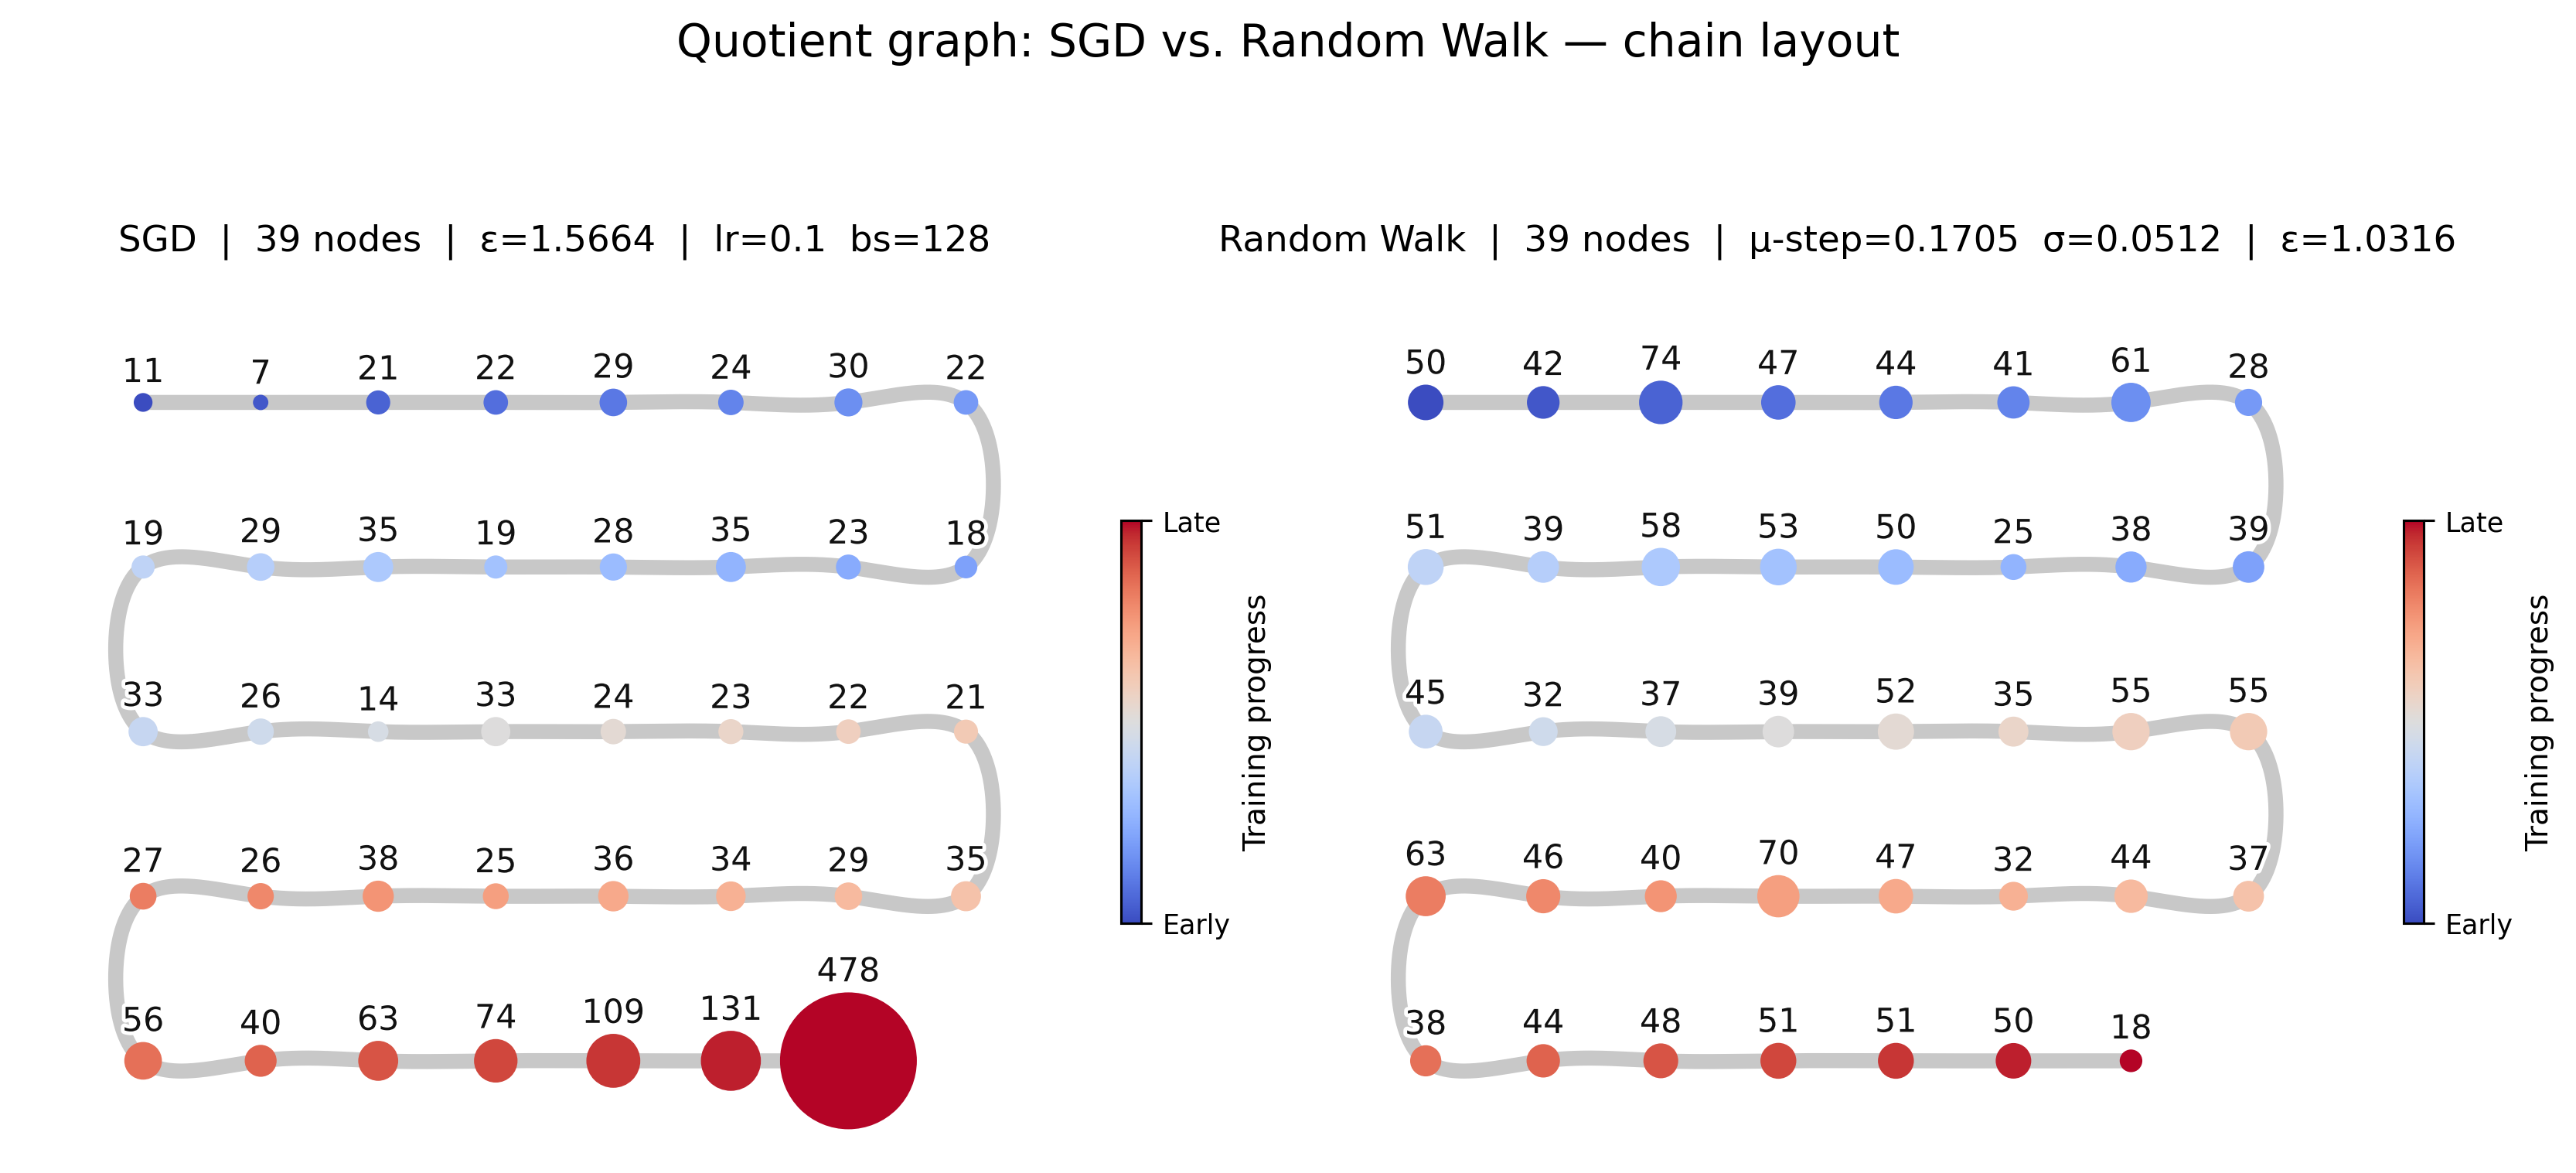

In [103]:
_chain_kw = dict(
    nodes_per_row=8, col_spacing=3.0, row_spacing=4.2,
    min_radius=0.150, max_radius=1.70, size_exponent=0.750,
    global_min_size=GLOBAL_MIN_SIZE, global_max_size=GLOBAL_MAX_SIZE,
    corner_bulge=0.7, path_lw=5,
    fs_title=12, fs_tick=9, fs_node=11, fs_cbar=10, title_pad=14)

_title_sgd = (f"SGD  |  {G_sgd.number_of_nodes()} nodes  |  "
              f"ε={eps_target:.4f}  |  lr={LR}  bs={BATCH_SIZE}")
_title_rw  = (f"Random Walk  |  {G_rw.number_of_nodes()} nodes  |  "
              f"μ-step={RW_STEP_MEAN:.4f}  σ={RW_STEP_STD:.4f}  |  "
              f"ε={eps_rw_target:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=280)

plot_graph_chain(G_sgd, axes[0], show_title=True, title=_title_sgd, **_chain_kw)
plot_graph_chain(G_rw,  axes[1], show_title=True, title=_title_rw,  **_chain_kw)

plt.suptitle('Quotient graph: SGD vs. Random Walk — chain layout',
             fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_42028/2518692261.py:78: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],


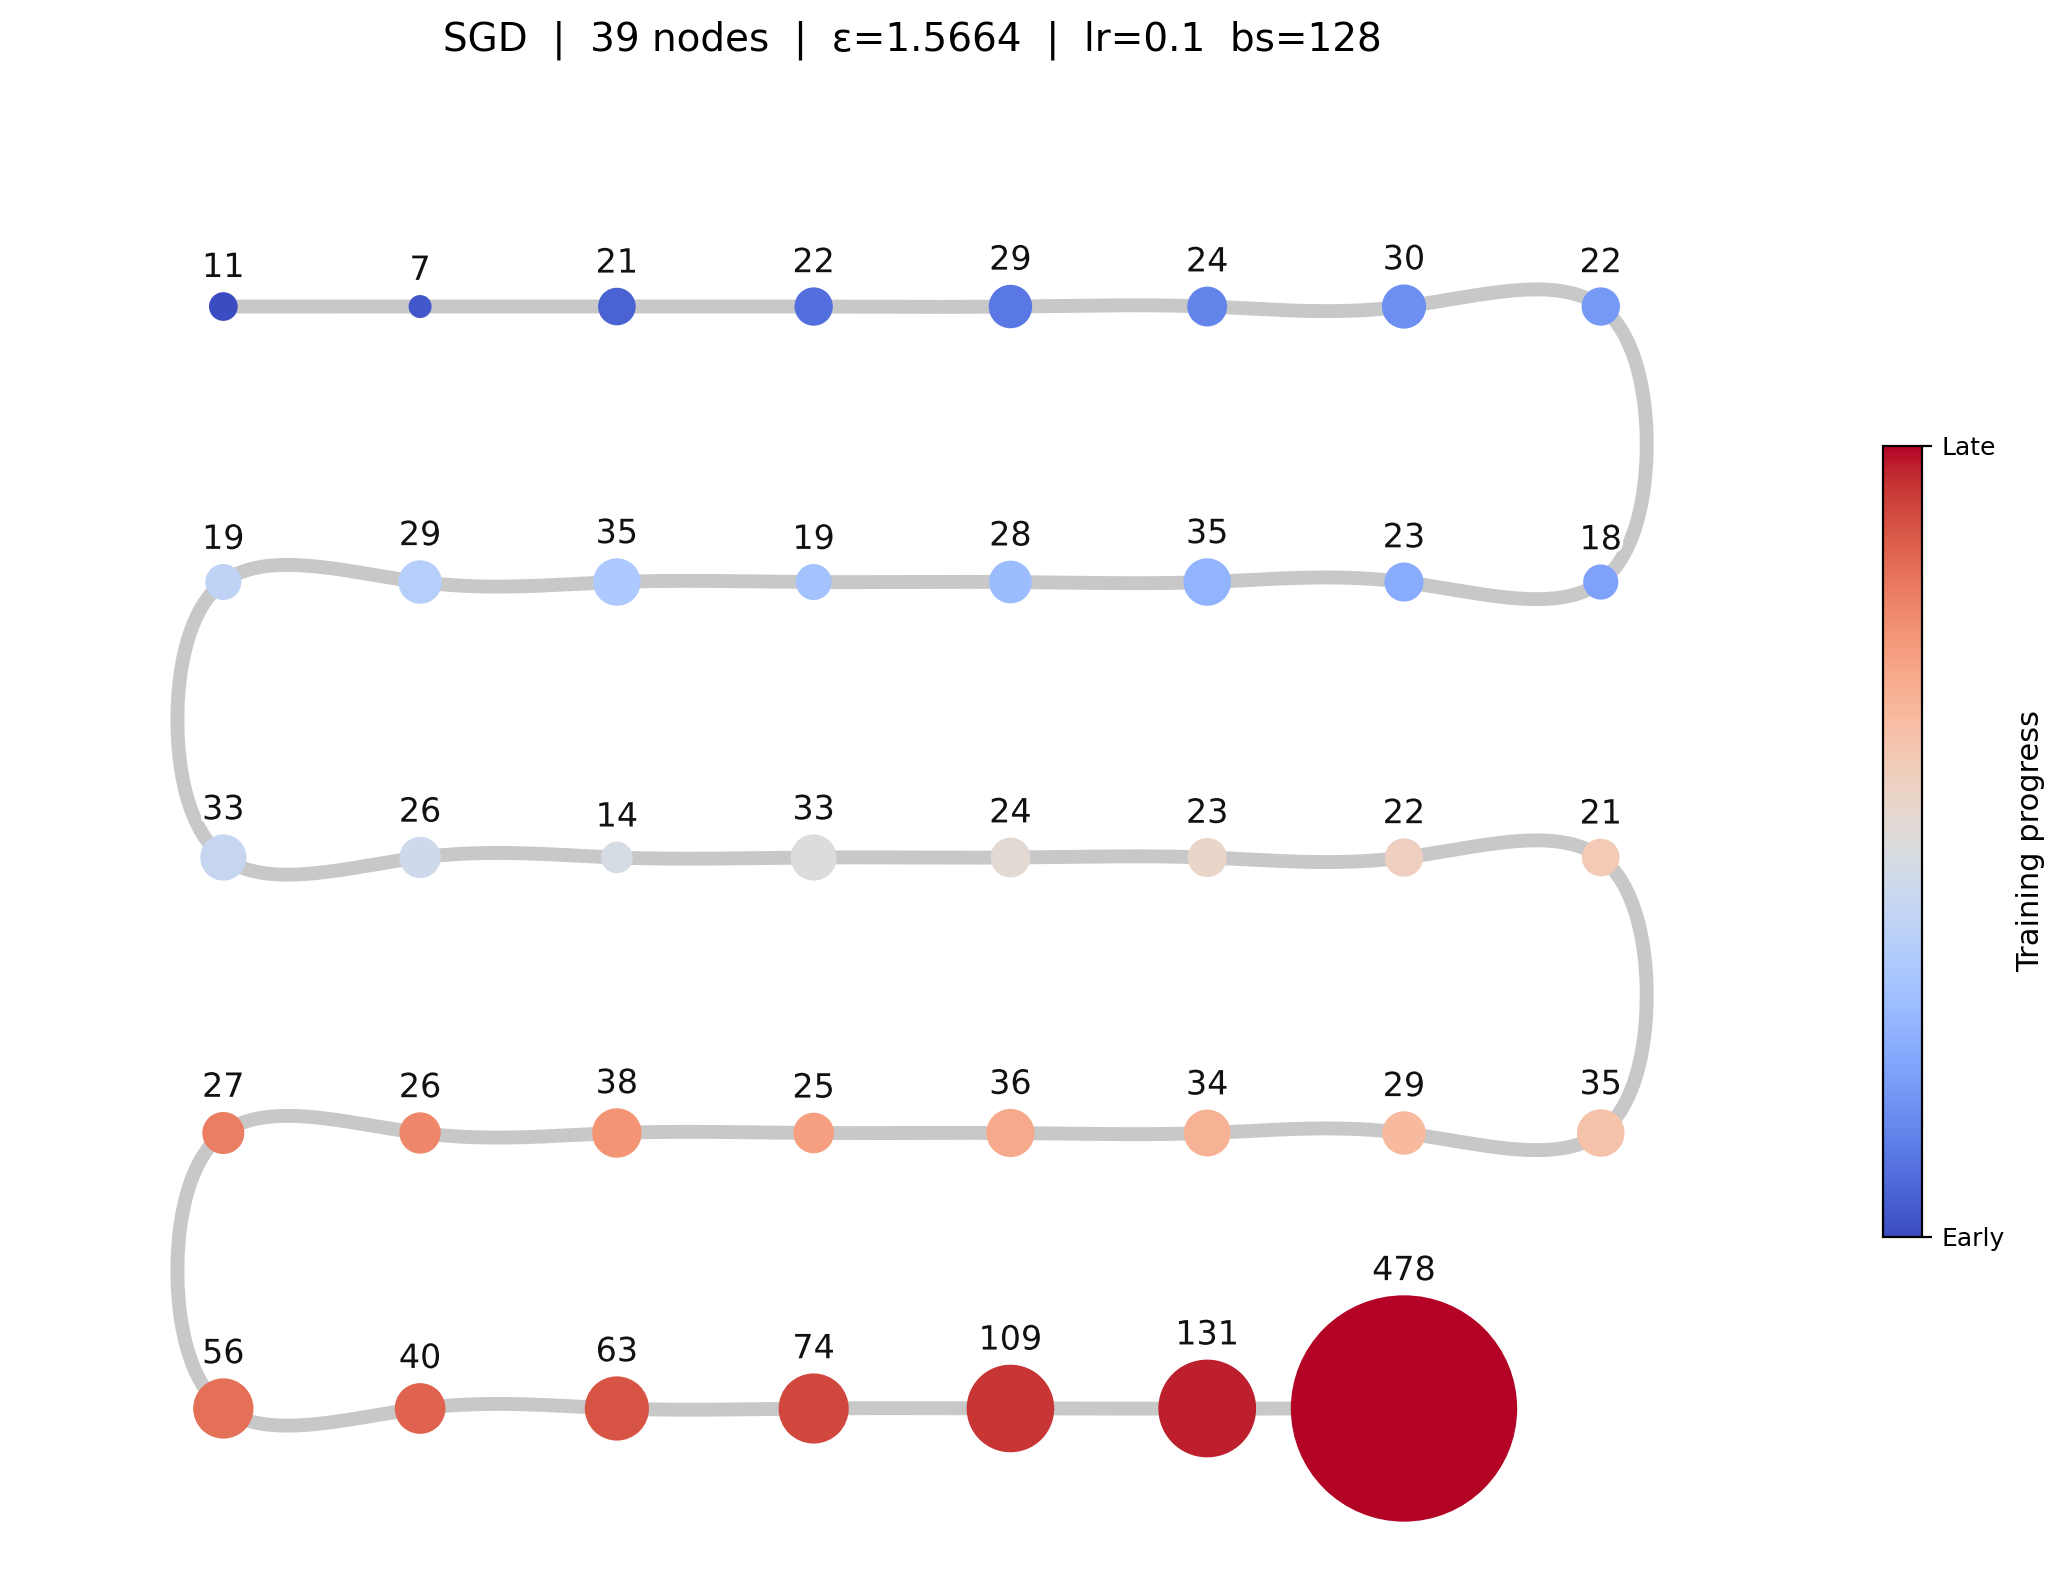

In [105]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=200)

plot_graph_chain(
    G_sgd, ax, show_title=True,   # Konfig-Titel bleibt
    title=_title_sgd,
    nodes_per_row=8, col_spacing=3.0, row_spacing=4.2,
    min_radius=0.15, max_radius=1.70, size_exponent=0.750,
    global_min_size=GLOBAL_MIN_SIZE, global_max_size=GLOBAL_MAX_SIZE,
    corner_bulge=0.7, path_lw=5,
    fs_title=14, fs_tick=9, fs_node=12, fs_cbar=11, title_pad=26)

plt.tight_layout(); plt.show()


  SGD  (lr=0.1  bs=128)
  Nodes:              39
  Edges:              38
  Self-loops:         39
  Has cycles:         no ✗
  Density:            0.02564
  Node size  μ / σ:   45.4 / 74.1
  Largest node:       478
  In-degree  μ:       0.974
  Out-degree μ:       0.974
  Mean path length:   13.333

  Random Walk  (μ=0.1705  σ=0.0512)
  Nodes:              39
  Edges:              38
  Self-loops:         39
  Has cycles:         no ✗
  Density:            0.02564
  Node size  μ / σ:   45.4 / 11.3
  Largest node:       74
  In-degree  μ:       0.974
  Out-degree μ:       0.974
  Mean path length:   13.333


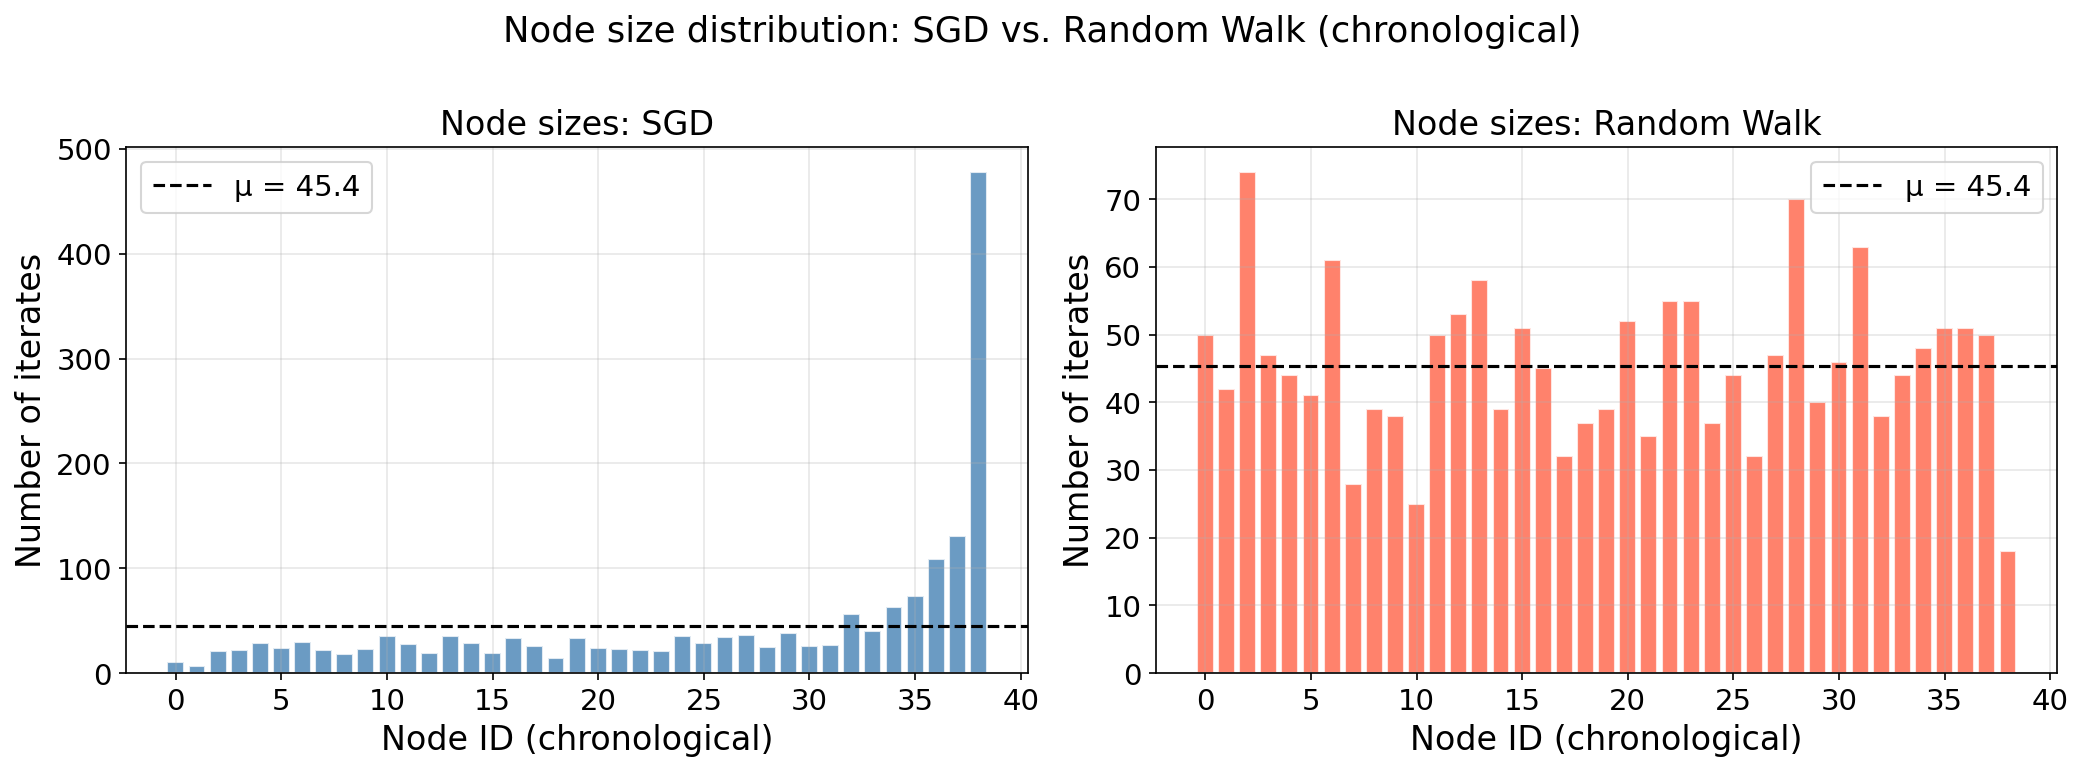

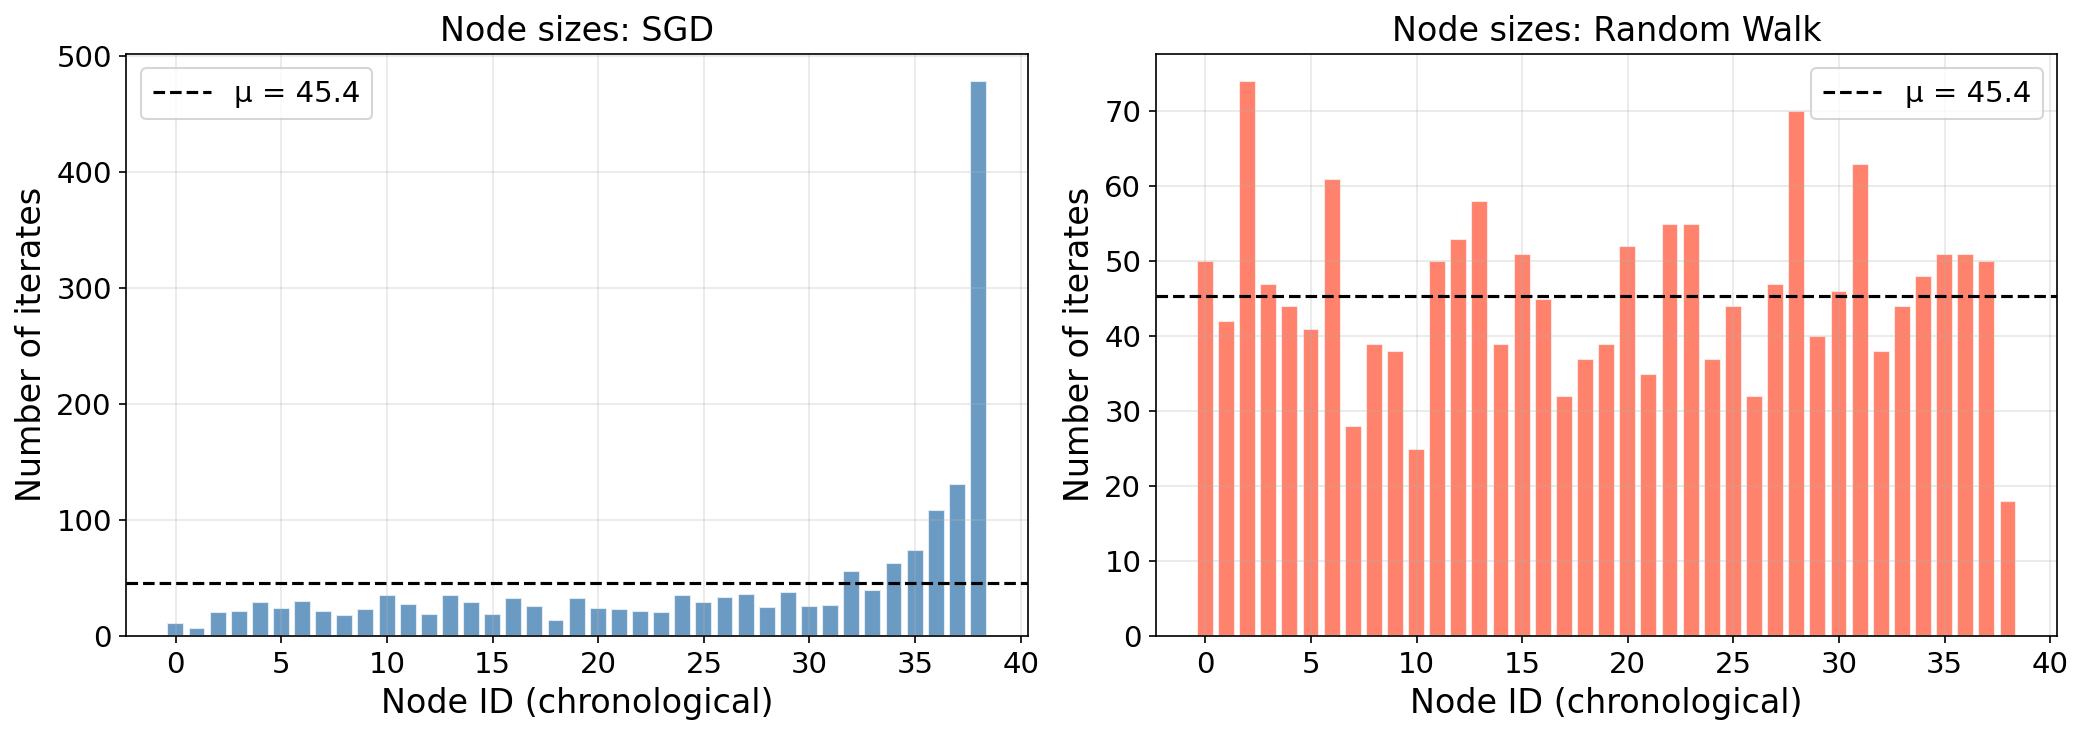

In [106]:
def graph_stats(G, label):
    G_s     = nx.DiGraph(G)
    G_s.remove_edges_from(nx.selfloop_edges(G_s))
    sizes   = [G.nodes[n]['size'] for n in G.nodes]
    in_d    = [d for _, d in G_s.in_degree()]
    out_d   = [d for _, d in G_s.out_degree()]
    has_cyc = not nx.is_directed_acyclic_graph(G_s)

    print(f"\n{'='*52}\n  {label}\n{'='*52}")
    print(f"  Nodes:              {G.number_of_nodes()}")
    print(f"  Edges:              {G_s.number_of_edges()}")
    print(f"  Self-loops:         {nx.number_of_selfloops(G)}")
    print(f"  Has cycles:         {'yes ✓' if has_cyc else 'no ✗'}")
    print(f"  Density:            {nx.density(G_s):.5f}")
    print(f"  Node size  μ / σ:   {np.mean(sizes):.1f} / {np.std(sizes):.1f}")
    print(f"  Largest node:       {max(sizes)}")
    print(f"  In-degree  μ:       {np.mean(in_d):.3f}")
    print(f"  Out-degree μ:       {np.mean(out_d):.3f}")
    try:
        wcc   = max(nx.weakly_connected_components(G_s), key=len)
        G_wcc = G_s.subgraph(wcc).copy()
        paths = [l for _, tgts in nx.all_pairs_shortest_path_length(G_wcc)
                 for t, l in tgts.items() if _ != t]
        print(f"  Mean path length:   {np.mean(paths):.3f}")
    except Exception:
        print(f"  Mean path length:   n/a")

graph_stats(G_sgd, f'SGD  (lr={LR}  bs={BATCH_SIZE})')
graph_stats(G_rw,  f'Random Walk  (μ={RW_STEP_MEAN:.4f}  σ={RW_STEP_STD:.4f})')

# ── Font sizes ────────────────────────────────────────────────────────────────
FS_TITLE  = 16
FS_LABEL  = 16
FS_TICK   = 14
FS_LEGEND = 14

def _plot_node_sizes(show_suptitle=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    for ax, G, label, color in [
            (axes[0], G_sgd, 'SGD',          'steelblue'),
            (axes[1], G_rw,  'Random Walk',   'tomato')]:
        sizes = [G.nodes[n]['size'] for n in sorted(G.nodes)]
        ax.bar(range(len(sizes)), sizes,
               color=color, alpha=0.8, edgecolor='white')
        ax.axhline(np.mean(sizes), color='black', ls='--', lw=1.5,
                   label=f'μ = {np.mean(sizes):.1f}')
        ax.set_xlabel('Node ID (chronological)', fontsize=FS_LABEL)
        ax.set_ylabel('Number of iterates',      fontsize=FS_LABEL)
        ax.set_title(f'Node sizes: {label}',     fontsize=FS_TITLE)
        ax.legend(fontsize=FS_LEGEND)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=FS_TICK)

    if show_suptitle:
        plt.suptitle('Node size distribution: SGD vs. Random Walk (chronological)',
                     fontsize=FS_TITLE + 1, y=1.02)

    plt.tight_layout()
    plt.show()

# ── Mit Obertitel ─────────────────────────────────────────────────────────────
_plot_node_sizes(show_suptitle=True)

# ── Ohne Obertitel ────────────────────────────────────────────────────────────
_plot_node_sizes(show_suptitle=False)

Tortuosity SGD:  μ=2.470  σ=1.040  median=2.228  (n=39 nodes)
Tortuosity RW:   μ=6.353  σ=0.837  median=6.395  (n=39 nodes)


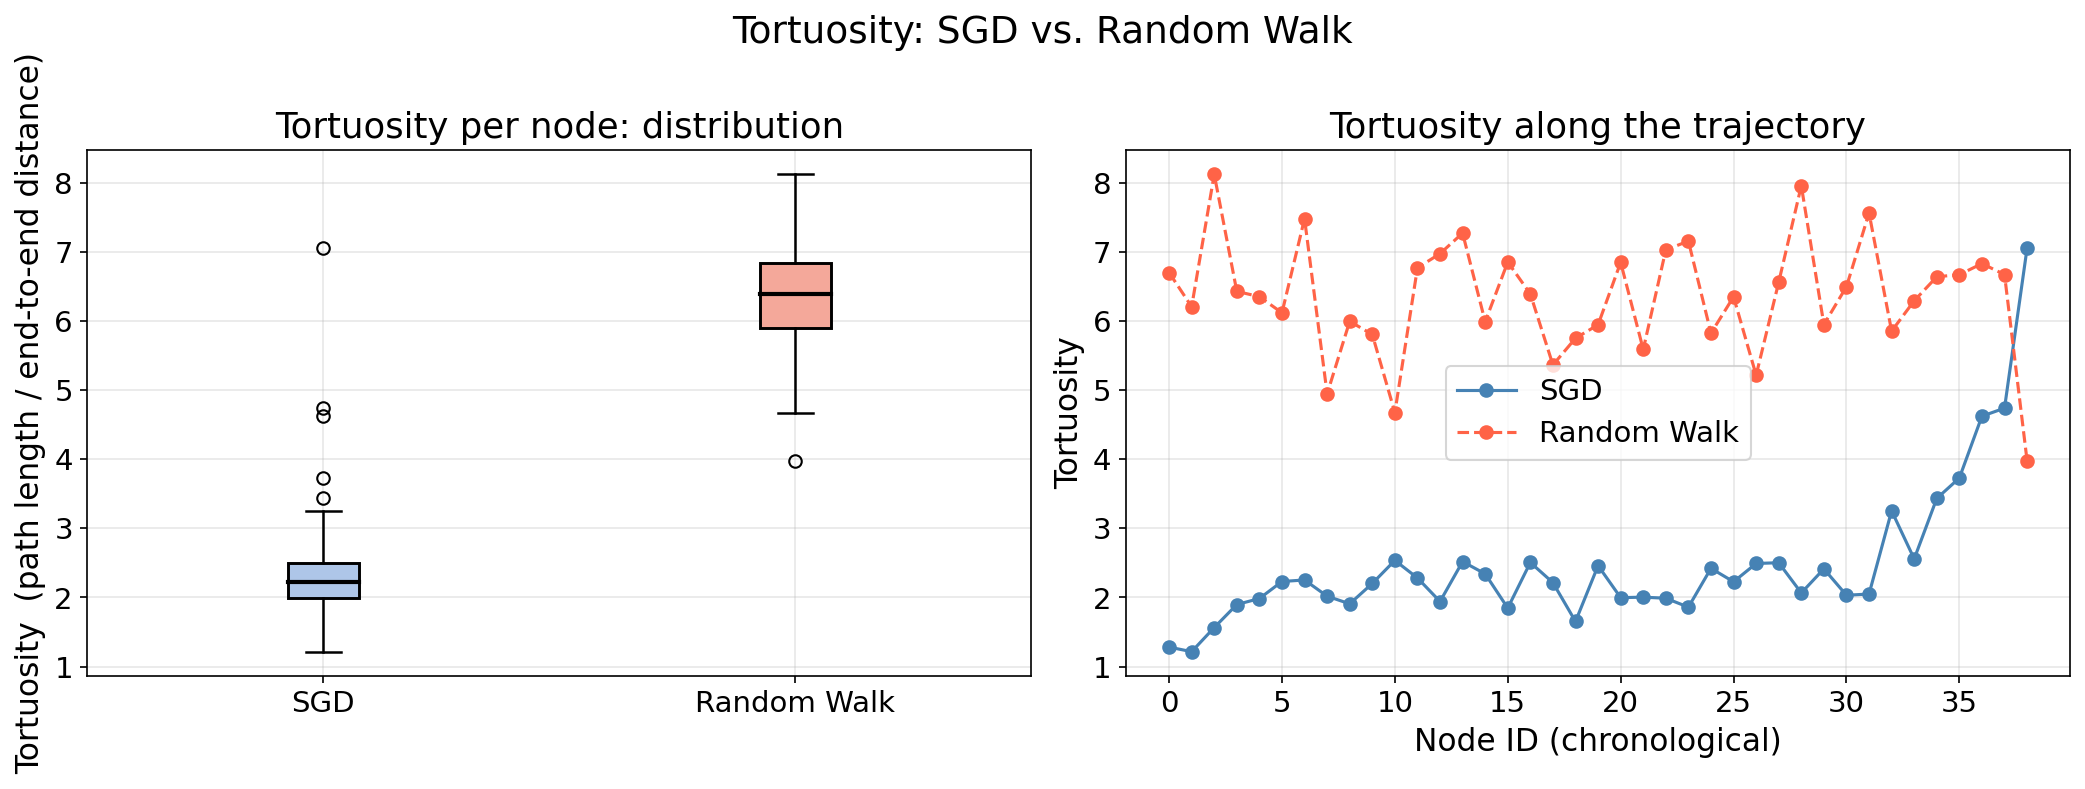

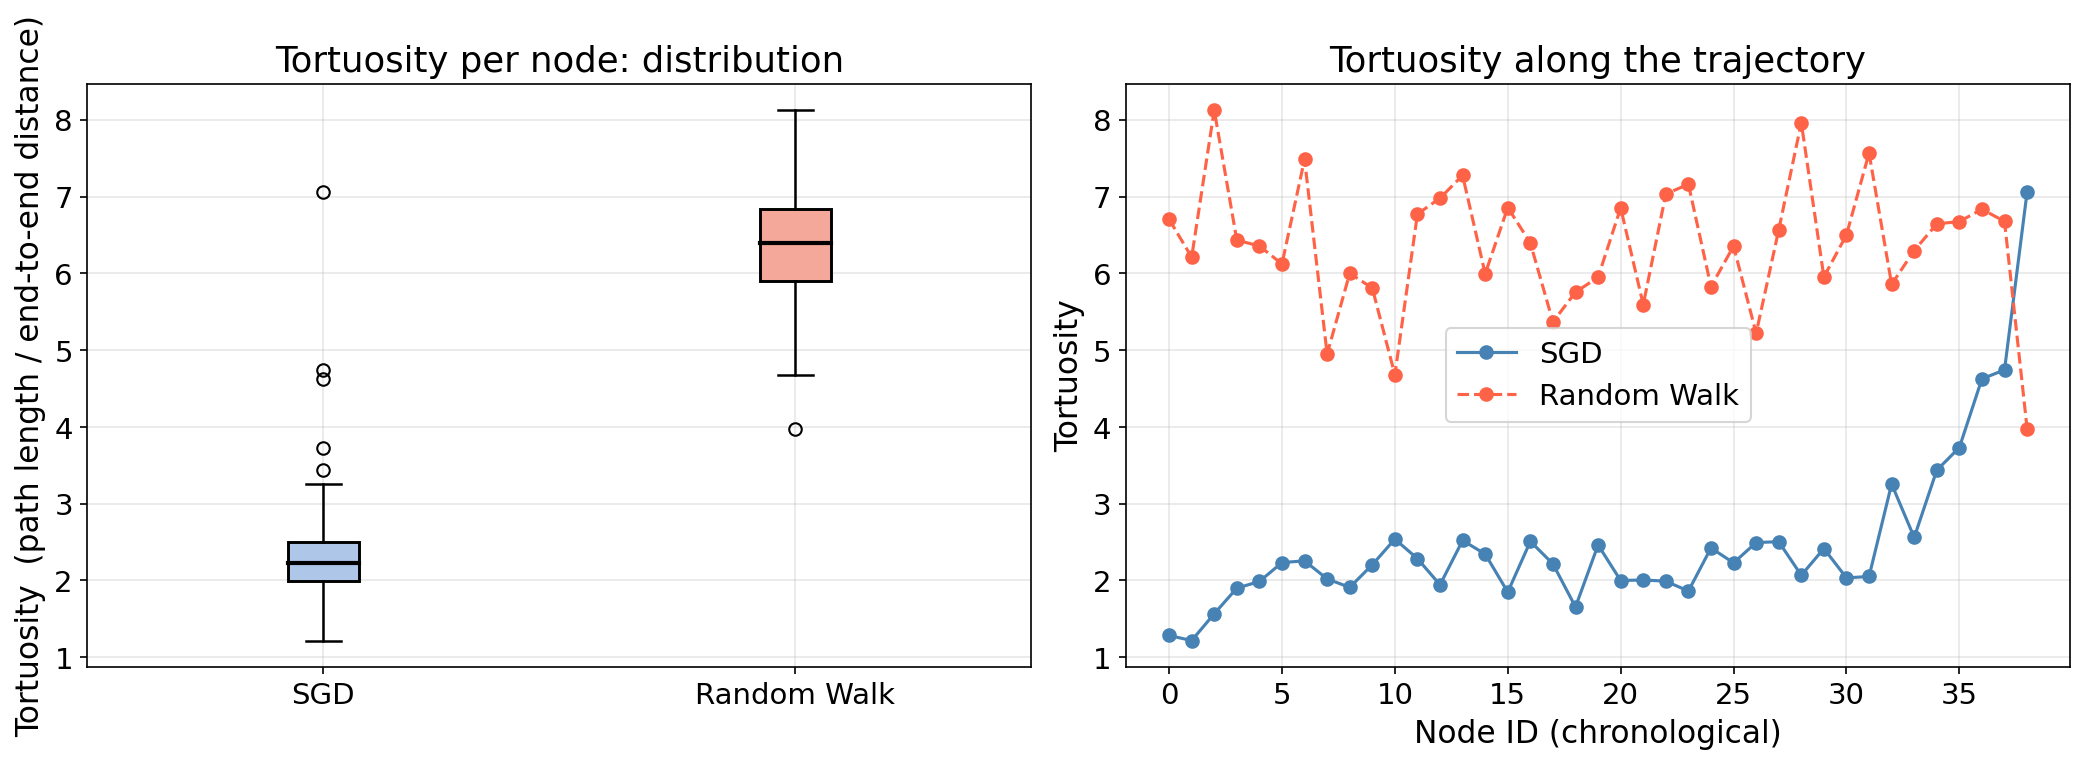

In [107]:
def node_tortuosity(iterates_full, labels, node_id):
    """
    Tortuosity = (sum of step lengths inside the node, chronological)
               / (Euclidean distance between first & last iterate of the node)
    Tortuosity = 1   → perfectly straight path
    Tortuosity >> 1  → strongly curved path
    """
    times = np.sort(np.where(labels == node_id)[0])
    if len(times) < 2:
        return np.nan, len(times)
    pts         = iterates_full[times]
    path_length = np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1))
    end_to_end  = np.linalg.norm(pts[-1] - pts[0])
    if end_to_end < 1e-12:
        return np.nan, len(times)
    return path_length / end_to_end, len(times)

tort_sgd = {nid: node_tortuosity(iterates_sel, labels_sgd, nid)[0]
            for nid in G_sgd.nodes}
tort_rw  = {nid: node_tortuosity(rw_iterates,  labels_rw,  nid)[0]
            for nid in G_rw.nodes}

tort_sgd_vals = np.array([v for v in tort_sgd.values() if not np.isnan(v)])
tort_rw_vals  = np.array([v for v in tort_rw.values()  if not np.isnan(v)])

print(f"Tortuosity SGD:  μ={tort_sgd_vals.mean():.3f}  σ={tort_sgd_vals.std():.3f}  "
      f"median={np.median(tort_sgd_vals):.3f}  (n={len(tort_sgd_vals)} nodes)")
print(f"Tortuosity RW:   μ={tort_rw_vals.mean():.3f}  σ={tort_rw_vals.std():.3f}  "
      f"median={np.median(tort_rw_vals):.3f}  (n={len(tort_rw_vals)} nodes)")

# ── Font sizes ────────────────────────────────────────────────────────────────
FS_TITLE  = 17
FS_LABEL  = 15
FS_TICK   = 14
FS_LEGEND = 14

def _plot_tortuosity(show_suptitle=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    # ── Left: boxplot ─────────────────────────────────────────────────────────
    bp = axes[0].boxplot(
        [tort_sgd_vals, tort_rw_vals],
        labels=['SGD', 'Random Walk'],
        patch_artist=True,
        boxprops=dict(linewidth=1.4),
        medianprops=dict(linewidth=2.0, color='black'),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2))

    bp['boxes'][0].set_facecolor('#aec6e8')
    bp['boxes'][1].set_facecolor('#f4a89a')

    axes[0].set_ylabel('Tortuosity  (path length / end-to-end distance)',
                       fontsize=FS_LABEL)
    axes[0].set_title('Tortuosity per node: distribution',
                      fontsize=FS_TITLE)
    axes[0].tick_params(labelsize=FS_TICK)
    axes[0].grid(alpha=0.3)

    # ── Right: line plot along trajectory ────────────────────────────────────
    ids_sgd = sorted(tort_sgd.keys())
    ids_rw  = sorted(tort_rw.keys())

    axes[1].plot(ids_sgd, [tort_sgd[i] for i in ids_sgd],
                 'o-', color='steelblue', label='SGD')
    axes[1].plot(ids_rw,  [tort_rw[i]  for i in ids_rw],
                 'o--', color='tomato', label='Random Walk')

    axes[1].set_xlabel('Node ID (chronological)', fontsize=FS_LABEL)
    axes[1].set_ylabel('Tortuosity',              fontsize=FS_LABEL)
    axes[1].set_title('Tortuosity along the trajectory',
                      fontsize=FS_TITLE)
    axes[1].legend(fontsize=FS_LEGEND)
    axes[1].tick_params(labelsize=FS_TICK)
    axes[1].grid(alpha=0.3)

    if show_suptitle:
        plt.suptitle('Tortuosity: SGD vs. Random Walk',
                     fontsize=FS_TITLE + 1,  y=1.02)

    plt.tight_layout()
    plt.show()

# ── Mit Obertitel ─────────────────────────────────────────────────────────────
_plot_tortuosity(show_suptitle=True)

# ── Ohne Obertitel ────────────────────────────────────────────────────────────
_plot_tortuosity(show_suptitle=False)